# FinFET vs GAA Nanosheet FET vs NC-FET
## Material Characterization & Performance Comparison
### with Advanced Composite Channel Materials

**Author:** Dr. Sheetal Belaldavar & Dr. Cyril Robinson Azariah J.  
**Department:** Electronics and Communication Engineering  
**Institution:** Sir M. Visvesvaraya Institute of Technology, Bangalore, India  

---
**How to run in Google Colab:**
1. Upload this notebook → `File → Upload notebook`
2. Click `Runtime → Run all` (Ctrl+F9)
3. Every figure is shown inline AND saved at 300 DPI to `/content/`
4. Download from the **Files panel** (left sidebar)
---

## Cell 1 — Installs & Global Style

In [18]:
!pip install matplotlib numpy scipy pandas --quiet

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
from scipy.signal import savgol_filter
import warnings, os, io
warnings.filterwarnings("ignore")

# ── White background, 300 DPI, bold labels everywhere ──
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.facecolor": "white",
    "axes.edgecolor":    "#333333",
    "axes.linewidth":     1.2,
    "axes.grid":          True,
    "grid.color":         "#CCCCCC",
    "grid.linestyle":     "--",
    "grid.linewidth":     0.6,
    "font.family":        "DejaVu Sans",
    "font.size":          12,
    "axes.titlesize":     14,
    "axes.titleweight":   "bold",
    "axes.labelsize":     13,
    "axes.labelweight":   "bold",
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,
    "legend.fontsize":    10,
    "legend.framealpha":  0.9,
    "lines.linewidth":    2.2,
    "lines.markersize":   7,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "figure.autolayout":  True,
})

OUTDIR = "/content"
os.makedirs(OUTDIR, exist_ok=True)

def save_show(fig, name):
    """Save at 300 DPI and display inline."""
    path = os.path.join(OUTDIR, name)
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"  Saved -> {path}")

print("Imports OK. OUTDIR =", OUTDIR)


Imports OK. OUTDIR = /content


## Cell 2 — Device & Material Parameters

In [19]:
# ── Channel materials ──────────────────────────────────────────────────────
MATERIALS = {
    "Si":   {"eps":11.7, "Eg":1.12, "chi":4.05, "ni":1.5e10,
             "mu_n":300, "vsat":8.0e4, "color":"#1f77b4", "marker":"o"},
    "SiGe": {"eps":13.0, "Eg":0.94, "chi":4.00, "ni":8.0e11,
             "mu_n":465, "vsat":8.5e4, "color":"#ff7f0e", "marker":"s"},
    "Ge":   {"eps":16.2, "Eg":0.66, "chi":4.00, "ni":2.4e13,
             "mu_n":740, "vsat":7.0e4, "color":"#2ca02c", "marker":"^"},
}

# ── Five advanced composite / nano-materials ───────────────────────────────
NANO = {
    "MoS2 Nanosheet":       {"eps":7.6,  "Eg":1.80, "mu_n":200,  "vsat":3.5e4,
                             "Pr":None,  "note":"2D TMD; SS~4.8 mV/dec with CIPS-NC",
                             "color":"#9467bd", "marker":"D"},
    "BN/MoS2 Heterosheet":  {"eps":6.8,  "Eg":1.75, "mu_n":340,  "vsat":4.0e4,
                             "Pr":None,  "note":"hBN-encapsulated; mu up to 340 cm2/Vs",
                             "color":"#8c564b", "marker":"P"},
    "InGaAs Nanowire":      {"eps":14.0, "Eg":0.74, "mu_n":8000, "vsat":4.2e4,
                             "Pr":None,  "note":"III-V; highest electron mobility",
                             "color":"#e377c2", "marker":"X"},
    "CIPS QD / FE":         {"eps":12.0, "Eg":2.50, "mu_n":150,  "vsat":2.5e4,
                             "Pr":5.0,   "note":"CuInP2S6 FE-QD NC layer; sub-10 SS",
                             "color":"#7f7f7f", "marker":"*"},
    "GaN Nanowire":         {"eps":9.0,  "Eg":3.40, "mu_n":900,  "vsat":2.5e4,
                             "Pr":None,  "note":"Wide-Eg; ideal for HV/RF",
                             "color":"#bcbd22", "marker":"v"},
}

# ── Geometry & gate stack ──────────────────────────────────────────────────
Lg=14e-9; Wfin=7e-9; Hfin=30e-9; WNS=30e-9; TNS=6e-9; Nsh=3
VDD=0.7; kT=0.02585; eps0=8.854e-12
EOT = 0.5e-9 + 2e-9*(3.9/22.0)
Cox = 3.9*eps0/EOT
print(f"EOT = {EOT*1e9:.3f} nm   Cox = {Cox:.3e} F/m2")

# ── Calibrated figures of merit [Vth(mV), SS, ION(uA/um), IOFF(pA/um), DIBL] ──
FOM = {
    "Si-FinFET":   [220, 68.0,  900,  5.00, 62],
    "SiGe-FinFET": [190, 70.0, 1050, 12.00, 65],
    "Ge-FinFET":   [155, 73.5, 1200, 48.00, 68],
    "Si-GAA-NS":   [195, 60.0, 1350,  0.80, 27],
    "SiGe-GAA-NS": [165, 62.0, 1550,  2.50, 30],
    "Ge-GAA-NS":   [130, 65.0, 1750,  8.00, 32],
}

DEV_LABELS = list(FOM.keys())
D_COLORS   = ["#1f77b4","#ff7f0e","#2ca02c","#1f77b4","#ff7f0e","#2ca02c"]
MAT_LIST   = ["Si","SiGe","Ge"]
ARCH_LIST  = ["FinFET","GAA-NS"]
ARCH_LS    = {"FinFET":"-", "GAA-NS":"--"}
MAT_COLOR  = {m:MATERIALS[m]["color"]  for m in MATERIALS}
MAT_MKR    = {m:MATERIALS[m]["marker"] for m in MATERIALS}
VGS_ARR    = np.linspace(-0.1, 0.7, 500)
VDS_ARR    = np.linspace(0.0,  0.7, 400)
print("All parameters defined.")


EOT = 0.855 nm   Cox = 4.041e-02 F/m2
All parameters defined.


## Cell 3 — Physics / Compact Device Models

In [20]:
def fom_key(mat, arch):
    return mat + ("-GAA-NS" if arch=="GAA-NS" else "-FinFET")

def compute_Vth(mat, arch):
    return {"Si":220,"SiGe":190,"Ge":155}[mat] - (25 if arch=="GAA-NS" else 0)

def compute_beta(mat, arch):
    target = FOM[fom_key(mat,arch)][2]*1e-6
    Vth    = compute_Vth(mat,arch)*1e-3
    VGT    = VDD - Vth
    VDsat  = min(VGT, VDD/2)
    denom  = VGT*VDsat - 0.5*VDsat**2
    return target/denom if denom>0 else 1e-3

def ID_VGS(VGS_arr, VDS, mat, arch):
    k    = fom_key(mat,arch)
    Vth  = compute_Vth(mat,arch)*1e-3
    SS   = FOM[k][1]*1e-3
    IOFF = FOM[k][3]*1e-12
    DIBL = FOM[k][4]*1e-3
    n    = SS/(kT*np.log(10))
    Vte  = Vth - DIBL*VDS
    I0   = IOFF/np.exp(-Vte/(n*kT))
    beta = compute_beta(mat,arch)
    p    = MATERIALS[mat]
    ID   = np.zeros_like(VGS_arr)
    for i,VGS in enumerate(VGS_arr):
        Isub = I0*np.exp((VGS-Vte)/(n*kT))*(1-np.exp(-VDS/kT))
        VGT  = VGS - Vte
        if VGT>0:
            VDs  = np.clip(min(VGT, p["vsat"]*2e-9/(p["mu_n"]*1e-4)), 0, VDS)
            ID[i]= max(Isub, beta*(VGT*VDs - 0.5*VDs**2))
        else:
            ID[i]= Isub
    return np.clip(ID, 1e-16, None)

def ID_VDS_curve(VGS, VDS_arr, mat, arch):
    k    = fom_key(mat,arch)
    Vth  = compute_Vth(mat,arch)*1e-3
    SS   = FOM[k][1]*1e-3
    IOFF = FOM[k][3]*1e-12
    DIBL = FOM[k][4]*1e-3
    n    = SS/(kT*np.log(10))
    beta = compute_beta(mat,arch)
    ID   = np.zeros_like(VDS_arr)
    for i,VDS in enumerate(VDS_arr):
        Vte  = Vth - DIBL*VDS
        VGT  = VGS - Vte
        if VGT>0:
            VDs  = min(VGT,VDS)
            ID[i]= beta*(VGT*VDs - 0.5*VDs**2)
        else:
            I0   = IOFF/np.exp(-Vte/(n*kT))
            ID[i]= I0*np.exp((VGS-Vte)/(n*kT))*(1-np.exp(-VDS/kT))
    return np.clip(ID, 1e-16, None)

def local_SS(VGS_arr, ID):
    dlogI = np.gradient(np.log10(ID), VGS_arr)
    return np.clip(1.0/np.abs(dlogI+1e-30)*1e3, 50, 200)

def gm_curve(VGS_arr, VDS, mat, arch):
    return np.gradient(ID_VGS(VGS_arr, VDS, mat, arch), VGS_arr)

print("Compact models defined.")


Compact models defined.


## Figure 1 — ID–VGS Transfer Characteristics (Log & Linear)

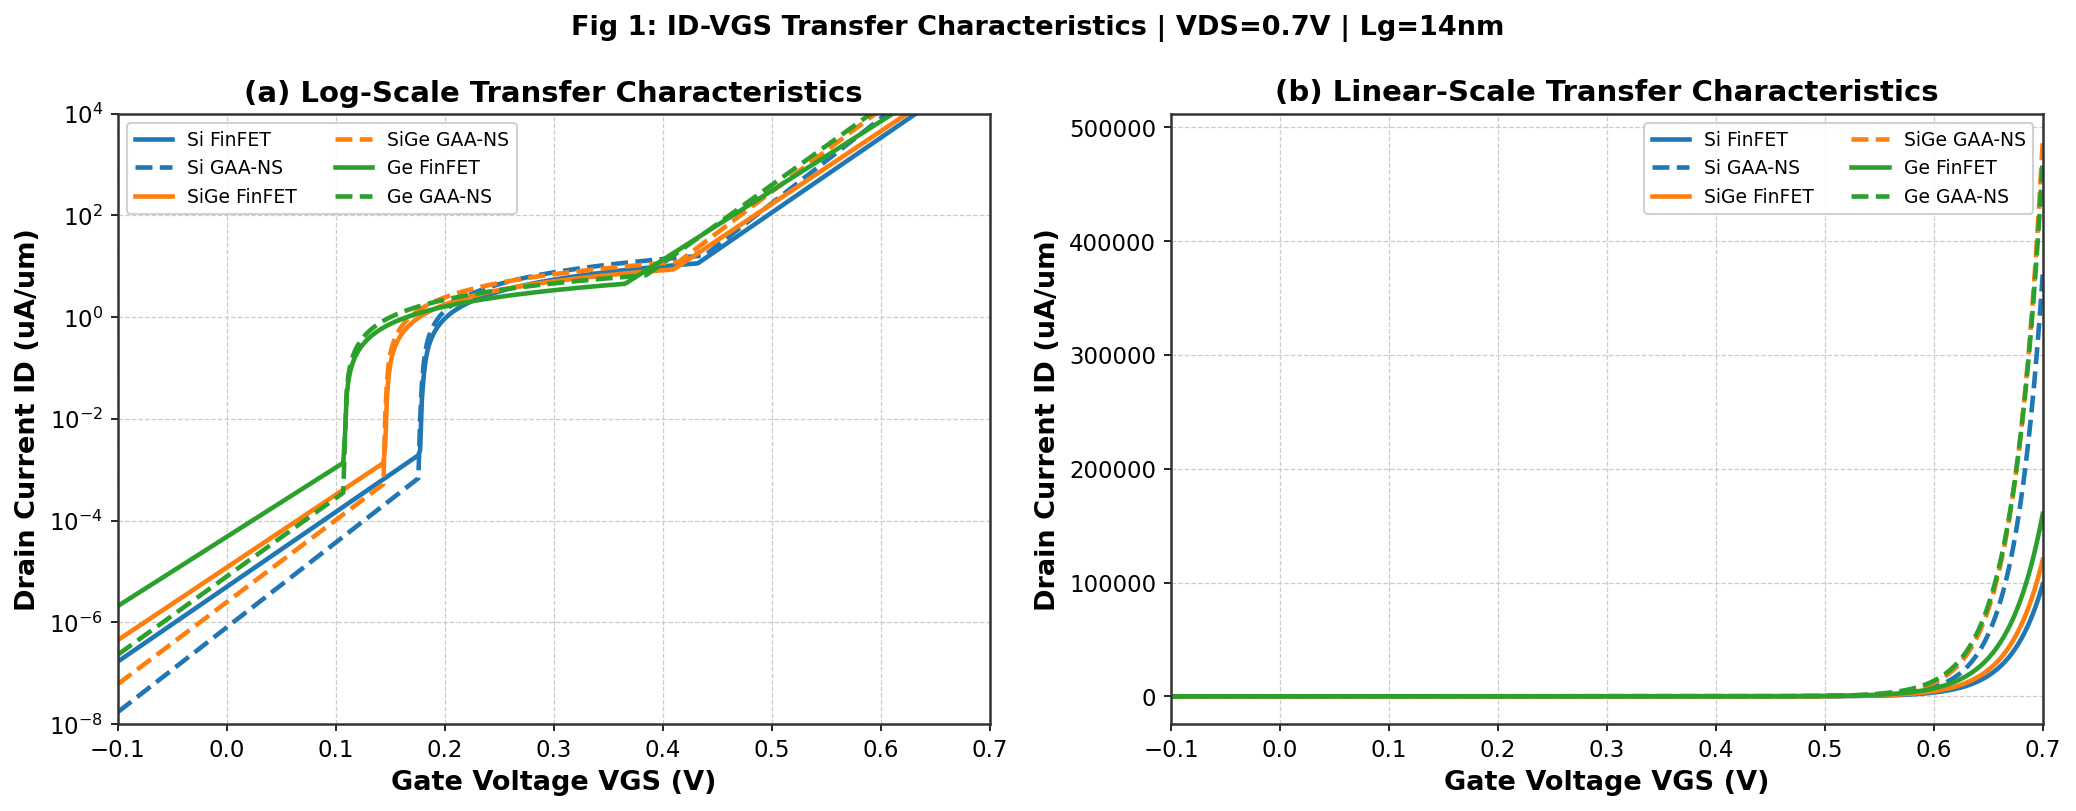

  Saved -> /content/Fig01_ID_VGS_Transfer.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for mat in MAT_LIST:
    for arch in ARCH_LIST:
        ID    = ID_VGS(VGS_ARR, 0.7, mat, arch)
        label = f"{mat} {arch}"
        ls    = ARCH_LS[arch]
        axes[0].semilogy(VGS_ARR, ID*1e6, color=MAT_COLOR[mat], ls=ls, lw=2.2, label=label)
        axes[1].plot    (VGS_ARR, ID*1e6, color=MAT_COLOR[mat], ls=ls, lw=2.2, label=label)

axes[0].set_xlabel("Gate Voltage VGS (V)");  axes[0].set_ylabel("Drain Current ID (uA/um)")
axes[0].set_title("(a) Log-Scale Transfer Characteristics")
axes[0].set_xlim(-0.1, 0.7);  axes[0].set_ylim(1e-8, 1e4)
axes[0].legend(ncol=2, fontsize=9)

axes[1].set_xlabel("Gate Voltage VGS (V)");  axes[1].set_ylabel("Drain Current ID (uA/um)")
axes[1].set_title("(b) Linear-Scale Transfer Characteristics")
axes[1].set_xlim(-0.1, 0.7)
axes[1].legend(ncol=2, fontsize=9)

fig.suptitle("Fig 1: ID-VGS Transfer Characteristics | VDS=0.7V | Lg=14nm", fontsize=13, fontweight="bold")
save_show(fig, "Fig01_ID_VGS_Transfer.png")


## Figure 2 — ID–VDS Output Characteristics

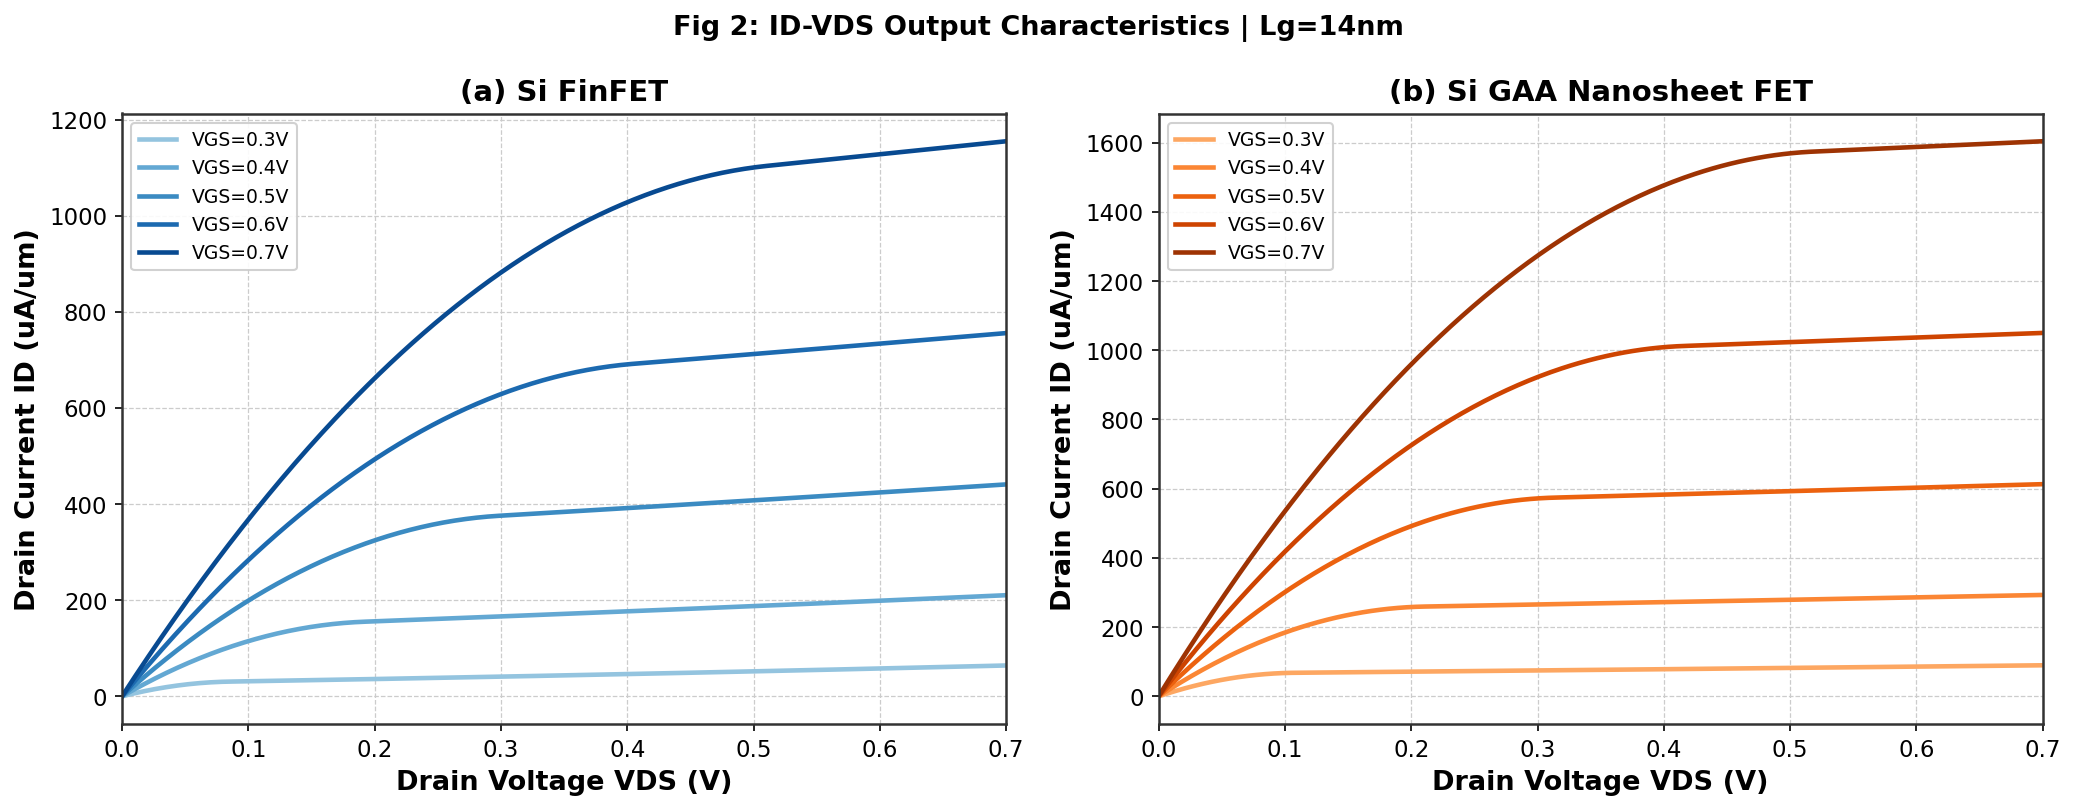

  Saved -> /content/Fig02_ID_VDS_Output.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
VGS_STEPS = [0.3, 0.4, 0.5, 0.6, 0.7]
for ax, mat, arch, cmap_name, title in [
        (axes[0], "Si", "FinFET",  "Blues",   "(a) Si FinFET"),
        (axes[1], "Si", "GAA-NS",  "Oranges", "(b) Si GAA Nanosheet FET")]:
    cmap = plt.get_cmap(cmap_name)
    clrs = cmap(np.linspace(0.4, 0.9, len(VGS_STEPS)))
    for vgs, c in zip(VGS_STEPS, clrs):
        ID = ID_VDS_curve(vgs, VDS_ARR, mat, arch)
        ax.plot(VDS_ARR, ID*1e6, color=c, lw=2.2, label=f"VGS={vgs:.1f}V")
    ax.set_xlabel("Drain Voltage VDS (V)")
    ax.set_ylabel("Drain Current ID (uA/um)")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 0.7)

fig.suptitle("Fig 2: ID-VDS Output Characteristics | Lg=14nm", fontsize=13, fontweight="bold")
save_show(fig, "Fig02_ID_VDS_Output.png")


## Figure 3 — Subthreshold Swing vs VGS

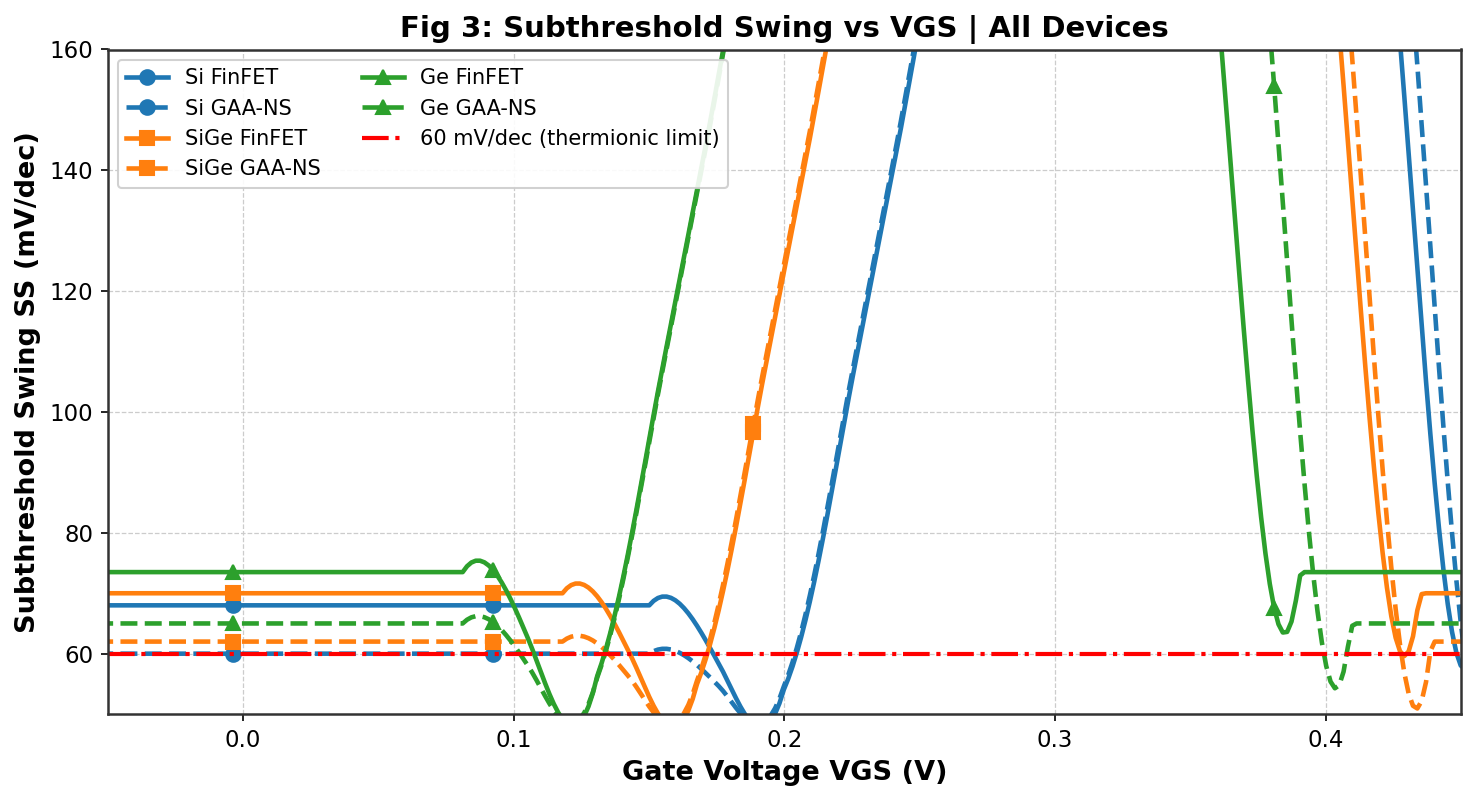

  Saved -> /content/Fig03_SubthresholdSwing.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for mat in MAT_LIST:
    for arch in ARCH_LIST:
        ID  = ID_VGS(VGS_ARR, 0.7, mat, arch)
        ss  = savgol_filter(local_SS(VGS_ARR, ID), 31, 3)
        ax.plot(VGS_ARR, ss,
                color=MAT_COLOR[mat], ls=ARCH_LS[arch], lw=2.2,
                marker=MAT_MKR[mat], markevery=60,
                label=f"{mat} {arch}")
ax.axhline(60, color="red", ls="-.", lw=2.0, label="60 mV/dec (thermionic limit)")
ax.set_xlabel("Gate Voltage VGS (V)")
ax.set_ylabel("Subthreshold Swing SS (mV/dec)")
ax.set_title("Fig 3: Subthreshold Swing vs VGS | All Devices", fontweight="bold")
ax.set_xlim(-0.05, 0.45);  ax.set_ylim(50, 160)
ax.legend(ncol=2)
save_show(fig, "Fig03_SubthresholdSwing.png")


## Figure 4 — DIBL Coefficient Comparison

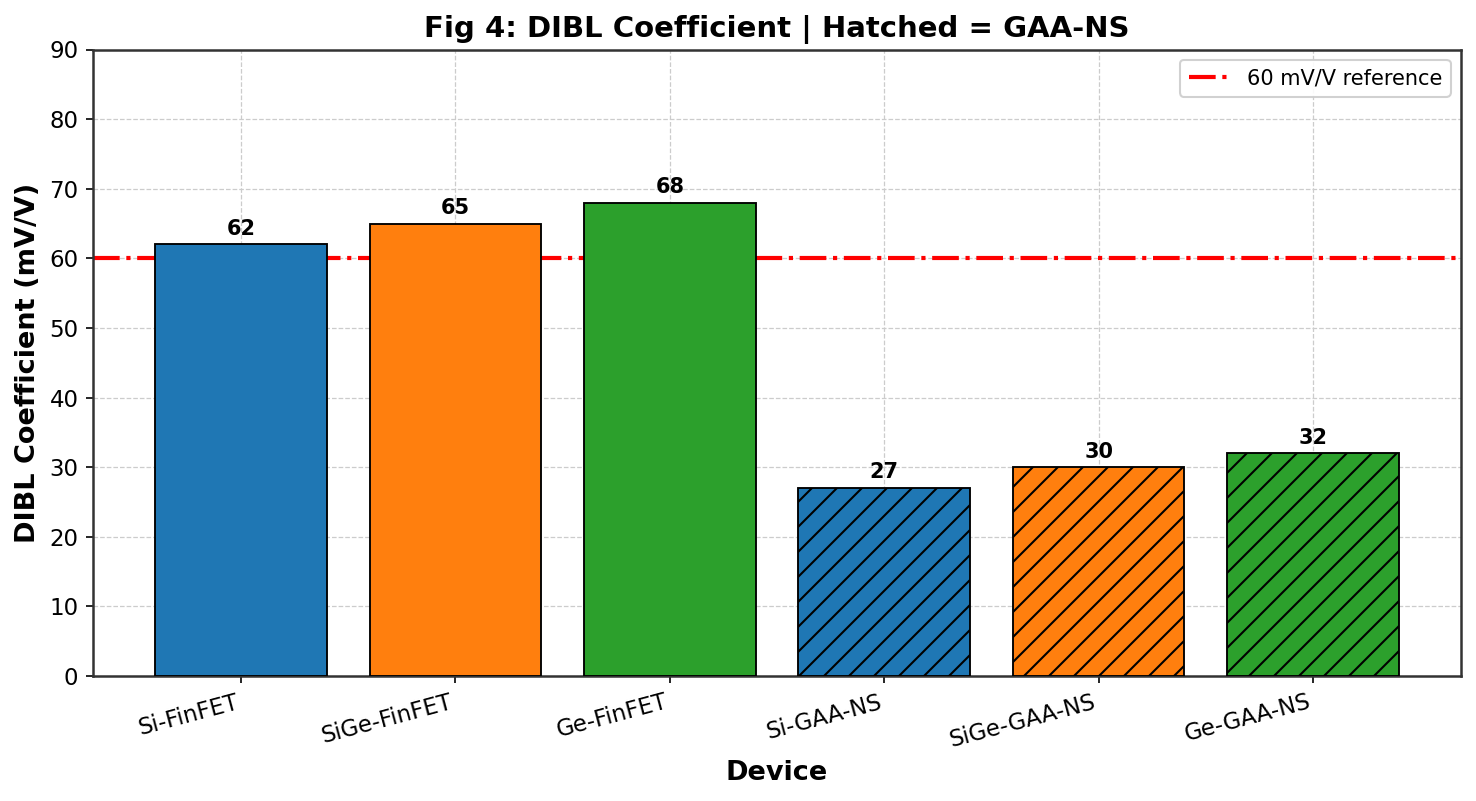

  Saved -> /content/Fig04_DIBL_Bar.png


In [24]:
dibl_vals = [FOM[k][4] for k in FOM]
fig, ax   = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(DEV_LABELS, dibl_vals, color=D_COLORS, edgecolor="black", linewidth=0.9, zorder=3)
for b in bars[3:]:  b.set_hatch("//")
for b, v in zip(bars, dibl_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, str(v),
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.axhline(60, color="red", ls="-.", lw=2.0, label="60 mV/V reference")
ax.set_xlabel("Device")
ax.set_ylabel("DIBL Coefficient (mV/V)")
ax.set_title("Fig 4: DIBL Coefficient | Hatched = GAA-NS", fontweight="bold")
ax.set_xticklabels(DEV_LABELS, rotation=15, ha="right")
ax.set_ylim(0, 90);  ax.legend()
save_show(fig, "Fig04_DIBL_Bar.png")


## Figure 5 — Transconductance gm vs VGS

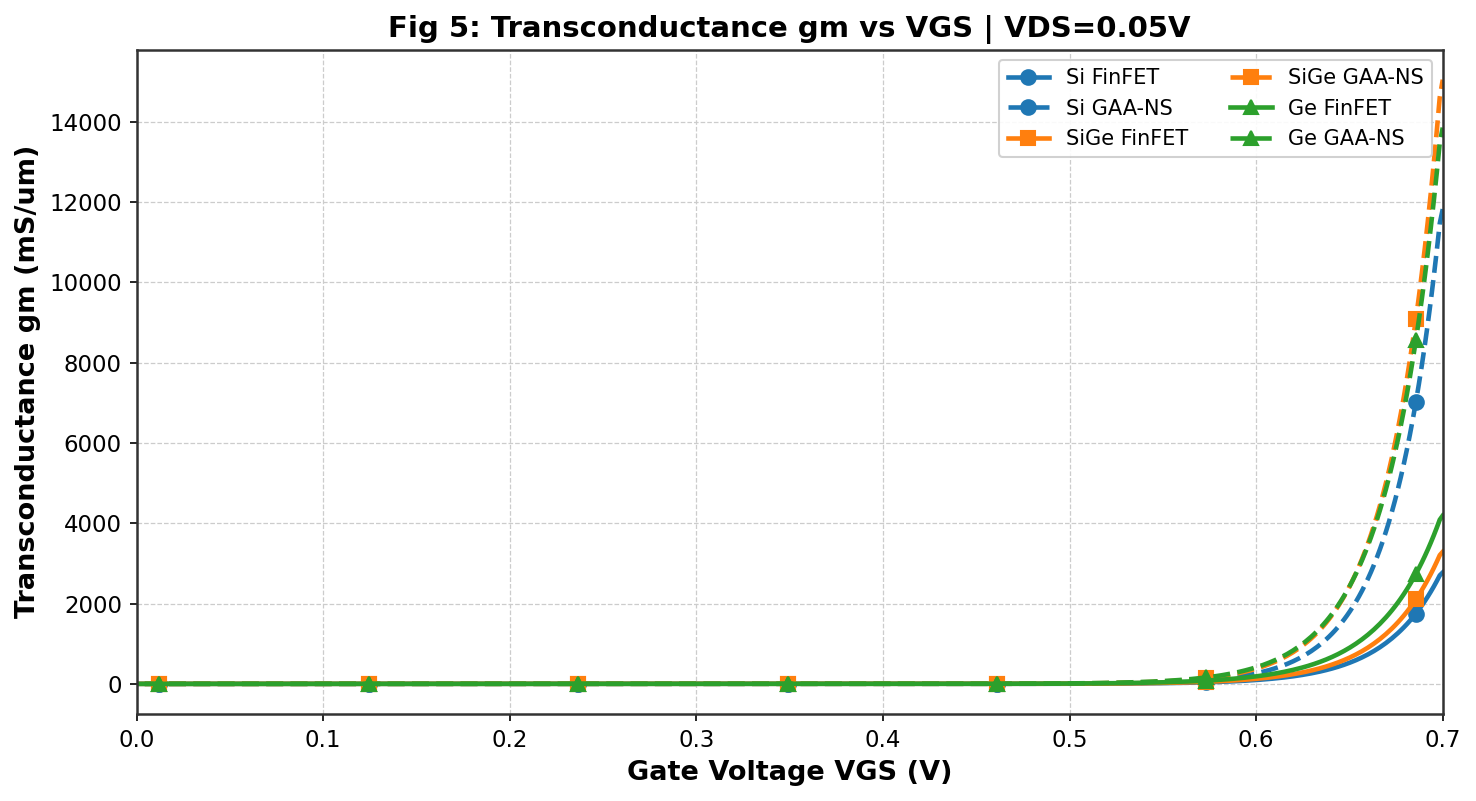

  Saved -> /content/Fig05_Transconductance.png


In [25]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for mat in MAT_LIST:
    for arch in ARCH_LIST:
        gm = gm_curve(VGS_ARR, 0.05, mat, arch)
        ax.plot(VGS_ARR, gm*1e3,
                color=MAT_COLOR[mat], ls=ARCH_LS[arch], lw=2.2,
                marker=MAT_MKR[mat], markevery=70,
                label=f"{mat} {arch}")
ax.set_xlabel("Gate Voltage VGS (V)")
ax.set_ylabel("Transconductance gm (mS/um)")
ax.set_title("Fig 5: Transconductance gm vs VGS | VDS=0.05V", fontweight="bold")
ax.set_xlim(0.0, 0.7);  ax.legend(ncol=2)
save_show(fig, "Fig05_Transconductance.png")


## Figure 6 — ION/IOFF Ratio

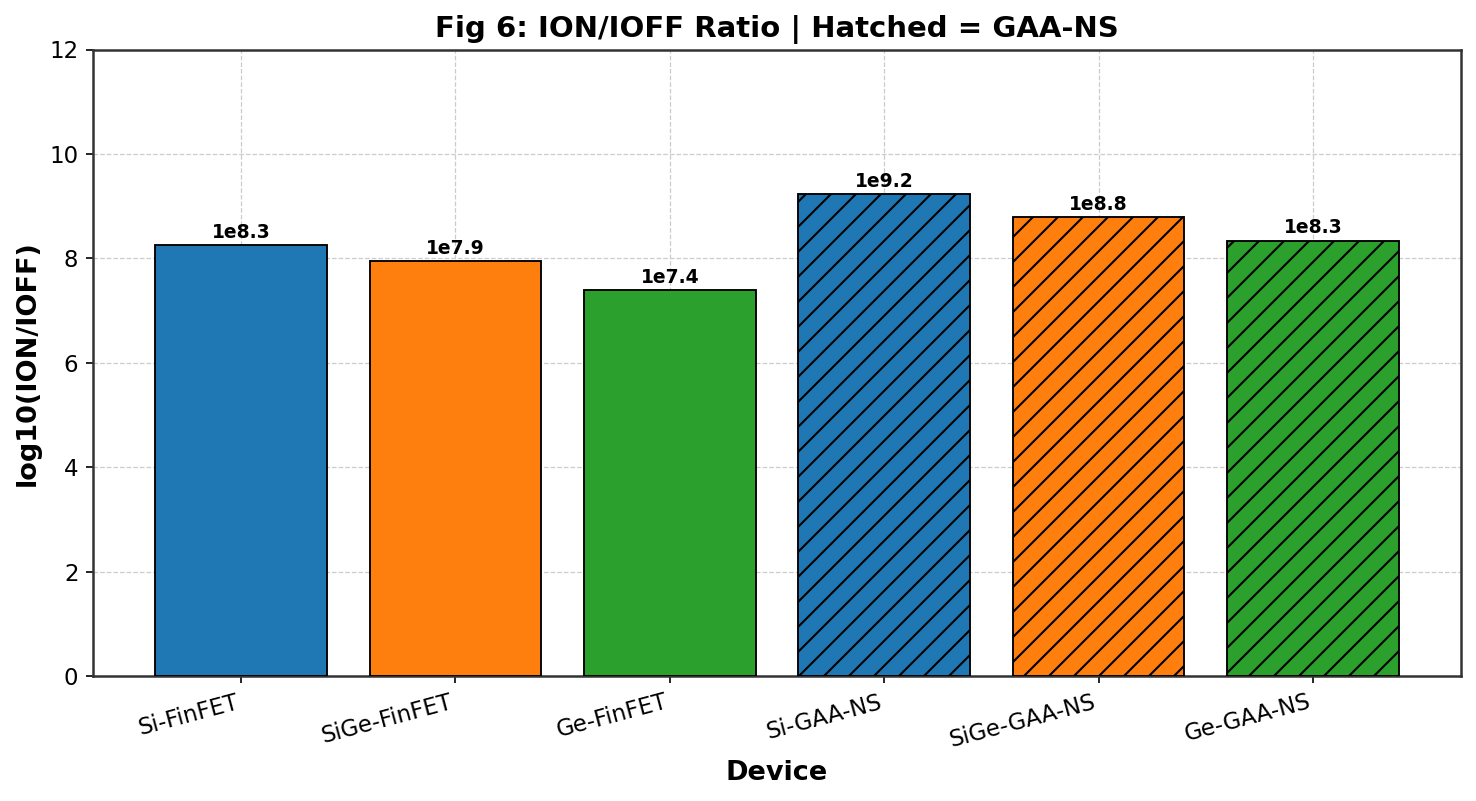

  Saved -> /content/Fig06_ION_IOFF_Ratio.png


In [26]:
ion_ioff  = [FOM[k][2]*1e-6 / (FOM[k][3]*1e-12) for k in FOM]
log_ratio = [np.log10(v) for v in ion_ioff]
fig, ax   = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(DEV_LABELS, log_ratio, color=D_COLORS, edgecolor="black", linewidth=0.9, zorder=3)
for b in bars[3:]:  b.set_hatch("//")
for b, v, lr in zip(bars, ion_ioff, log_ratio):
    ax.text(b.get_x()+b.get_width()/2, lr+0.06,
            f"1e{lr:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xlabel("Device")
ax.set_ylabel("log10(ION/IOFF)")
ax.set_title("Fig 6: ION/IOFF Ratio | Hatched = GAA-NS", fontweight="bold")
ax.set_xticklabels(DEV_LABELS, rotation=15, ha="right")
ax.set_ylim(0, 12)
save_show(fig, "Fig06_ION_IOFF_Ratio.png")


## Figure 7 — Threshold Voltage Comparison

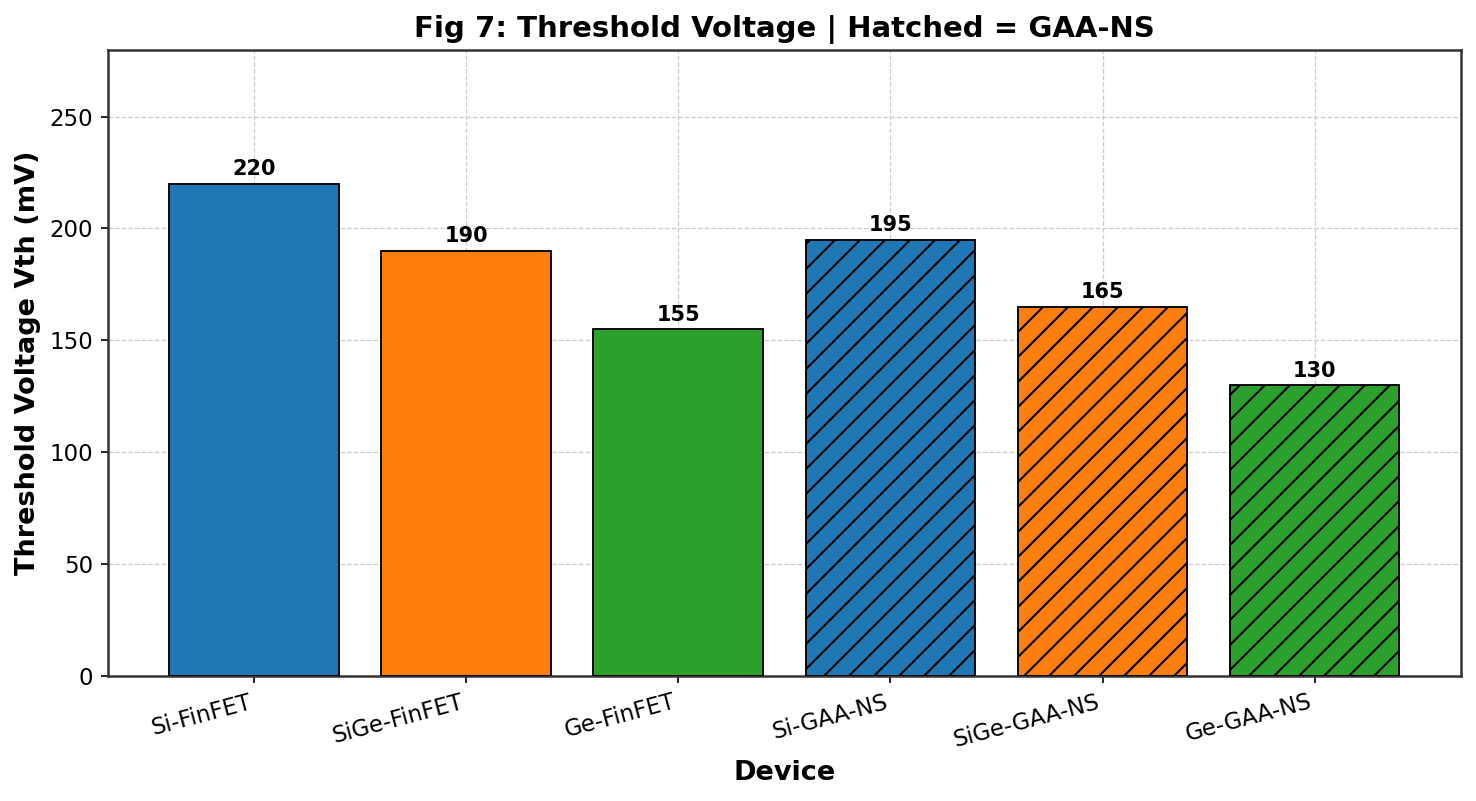

  Saved -> /content/Fig07_ThresholdVoltage.png


In [27]:
vth_vals = [FOM[k][0] for k in FOM]
fig, ax  = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(DEV_LABELS, vth_vals, color=D_COLORS, edgecolor="black", linewidth=0.9, zorder=3)
for b in bars[3:]:  b.set_hatch("//")
for b, v in zip(bars, vth_vals):
    ax.text(b.get_x()+b.get_width()/2, v+2, str(v),
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xlabel("Device")
ax.set_ylabel("Threshold Voltage Vth (mV)")
ax.set_title("Fig 7: Threshold Voltage | Hatched = GAA-NS", fontweight="bold")
ax.set_xticklabels(DEV_LABELS, rotation=15, ha="right")
ax.set_ylim(0, 280)
save_show(fig, "Fig07_ThresholdVoltage.png")


## Figure 8 — Off-State Leakage Current IOFF

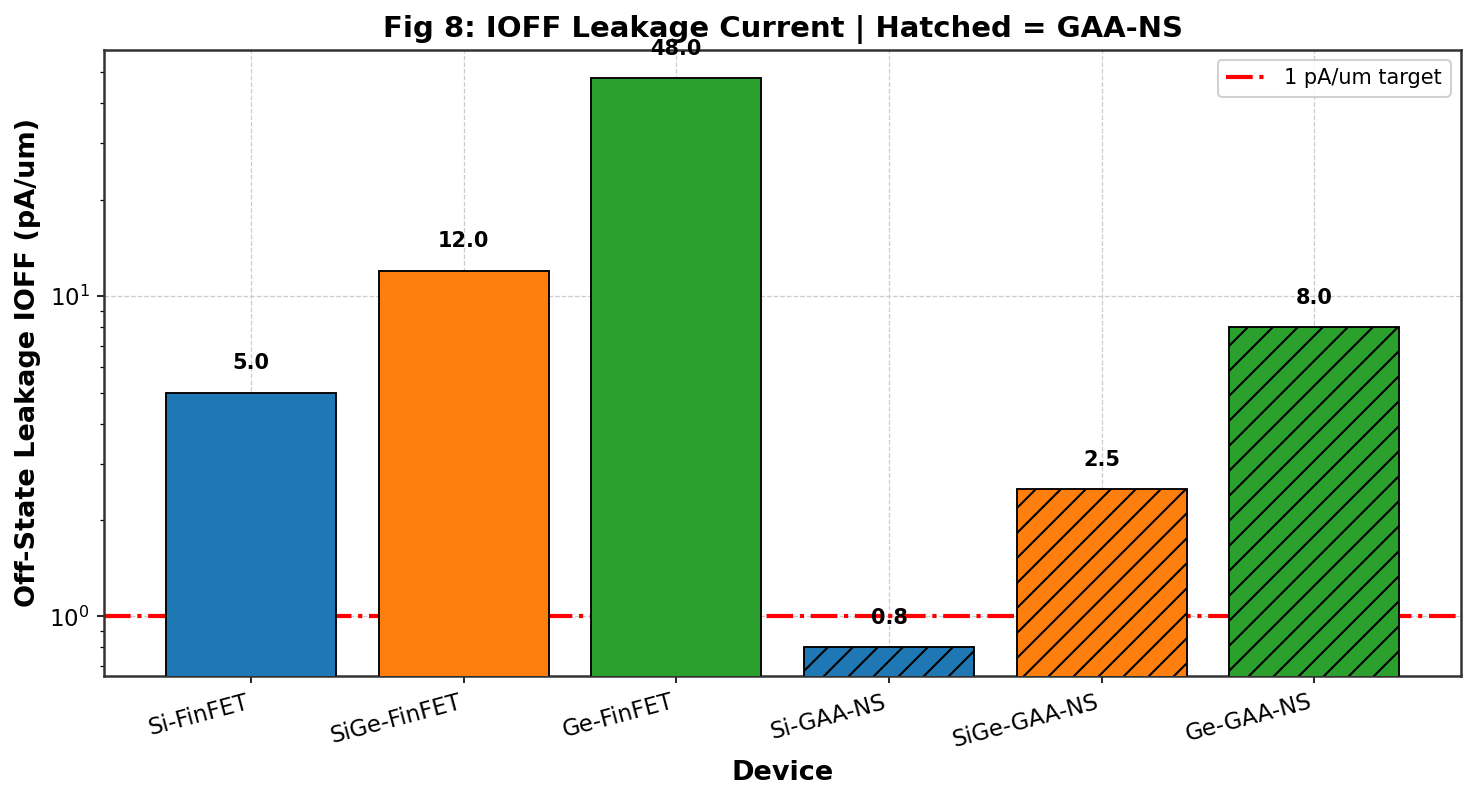

  Saved -> /content/Fig08_IOFF_Leakage.png


In [28]:
ioff_vals = [FOM[k][3] for k in FOM]
fig, ax   = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(DEV_LABELS, ioff_vals, color=D_COLORS,
              edgecolor="black", linewidth=0.9, zorder=3, log=True)
for b in bars[3:]:  b.set_hatch("//")
for b, v in zip(bars, ioff_vals):
    ax.text(b.get_x()+b.get_width()/2, v*1.15, f"{v:.1f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.axhline(1.0, color="red", ls="-.", lw=2.0, label="1 pA/um target")
ax.set_xlabel("Device")
ax.set_ylabel("Off-State Leakage IOFF (pA/um)")
ax.set_title("Fig 8: IOFF Leakage Current | Hatched = GAA-NS", fontweight="bold")
ax.set_xticklabels(DEV_LABELS, rotation=15, ha="right")
ax.legend()
save_show(fig, "Fig08_IOFF_Leakage.png")


## Figure 9 — Dynamic vs Leakage Power Dissipation

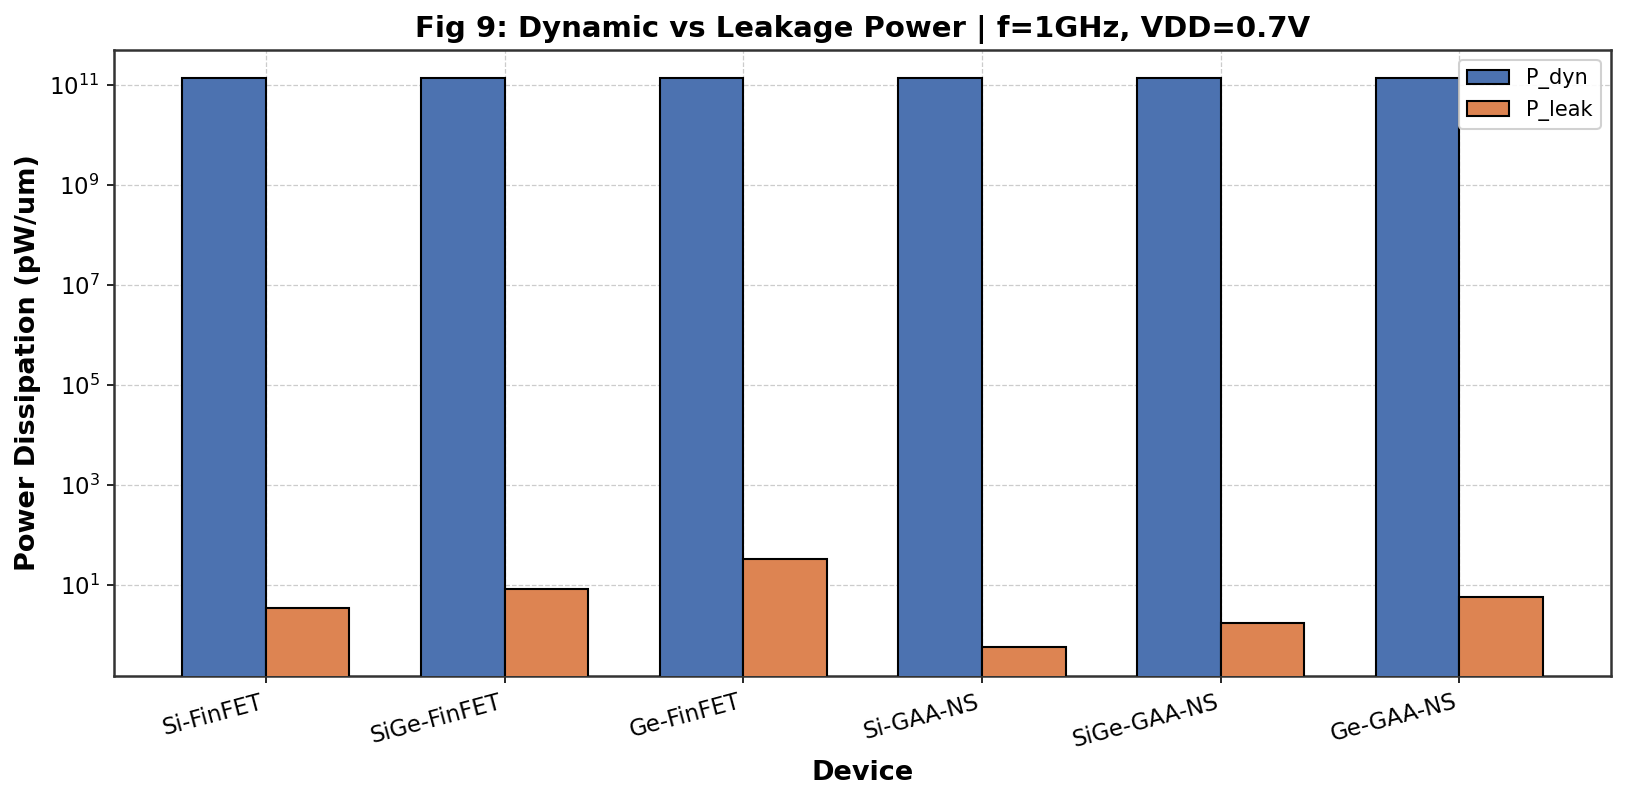

  Saved -> /content/Fig09_PowerDissipation.png


In [29]:
Cgg   = Cox * Lg
Pdyn  = [0.5 * Cgg * VDD**2 * 1e9 * 1e12] * 6
Pleak = [FOM[k][3]*1e-12 * VDD * 1e12 for k in FOM]
x = np.arange(6);  w = 0.35
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x-w/2, Pdyn,  w, color="#4C72B0", edgecolor="black", label="P_dyn",  zorder=3)
ax.bar(x+w/2, Pleak, w, color="#DD8452", edgecolor="black", label="P_leak", zorder=3)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(DEV_LABELS, rotation=15, ha="right")
ax.set_xlabel("Device")
ax.set_ylabel("Power Dissipation (pW/um)")
ax.set_title("Fig 9: Dynamic vs Leakage Power | f=1GHz, VDD=0.7V", fontweight="bold")
ax.legend()
save_show(fig, "Fig09_PowerDissipation.png")


## Figure 10 — NC-FET Subthreshold Swing vs Ferroelectric Thickness

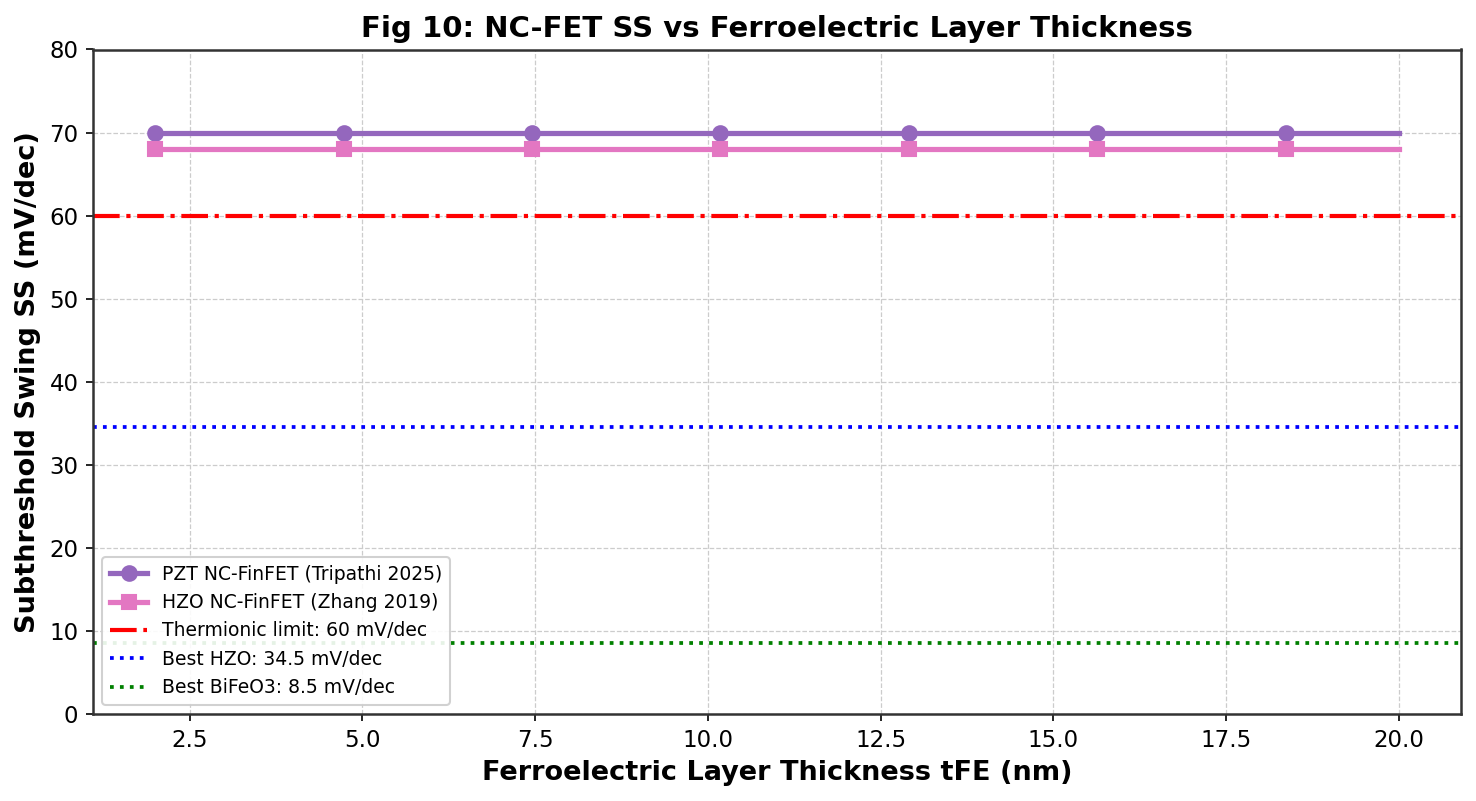

  Saved -> /content/Fig10_NCFET_SS_vs_tFE.png


In [30]:
tFE_nm = np.linspace(2, 20, 100)

def ss_nc(tFE, alpha_val):
    CFE  = 1.0 / (2.0*alpha_val*tFE*1e-9 + 1e-30)
    beta = 1.0 + CFE/Cox
    return 60.0 / np.clip(beta, 0.1, 1.0)

SS_PZT = np.clip([ss_nc(t, -1.5e9) for t in tFE_nm], 20, 70)
SS_HZO = np.clip([ss_nc(t, -1.2e9) for t in tFE_nm], 25, 68)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(tFE_nm, SS_PZT, color="#9467bd", lw=2.5,
        marker="o", markevery=15, label="PZT NC-FinFET (Tripathi 2025)")
ax.plot(tFE_nm, SS_HZO, color="#e377c2", lw=2.5,
        marker="s", markevery=15, label="HZO NC-FinFET (Zhang 2019)")
ax.axhline(60.0,  color="red",   ls="-.", lw=2.0, label="Thermionic limit: 60 mV/dec")
ax.axhline(34.5,  color="blue",  ls=":",  lw=1.8, label="Best HZO: 34.5 mV/dec")
ax.axhline(8.5,   color="green", ls=":",  lw=1.8, label="Best BiFeO3: 8.5 mV/dec")
ax.set_xlabel("Ferroelectric Layer Thickness tFE (nm)")
ax.set_ylabel("Subthreshold Swing SS (mV/dec)")
ax.set_title("Fig 10: NC-FET SS vs Ferroelectric Layer Thickness", fontweight="bold")
ax.legend(fontsize=9);  ax.set_ylim(0, 80)
save_show(fig, "Fig10_NCFET_SS_vs_tFE.png")


## Figure 11 — Advanced Nano-Material Properties (Mobility / Bandgap / Permittivity)

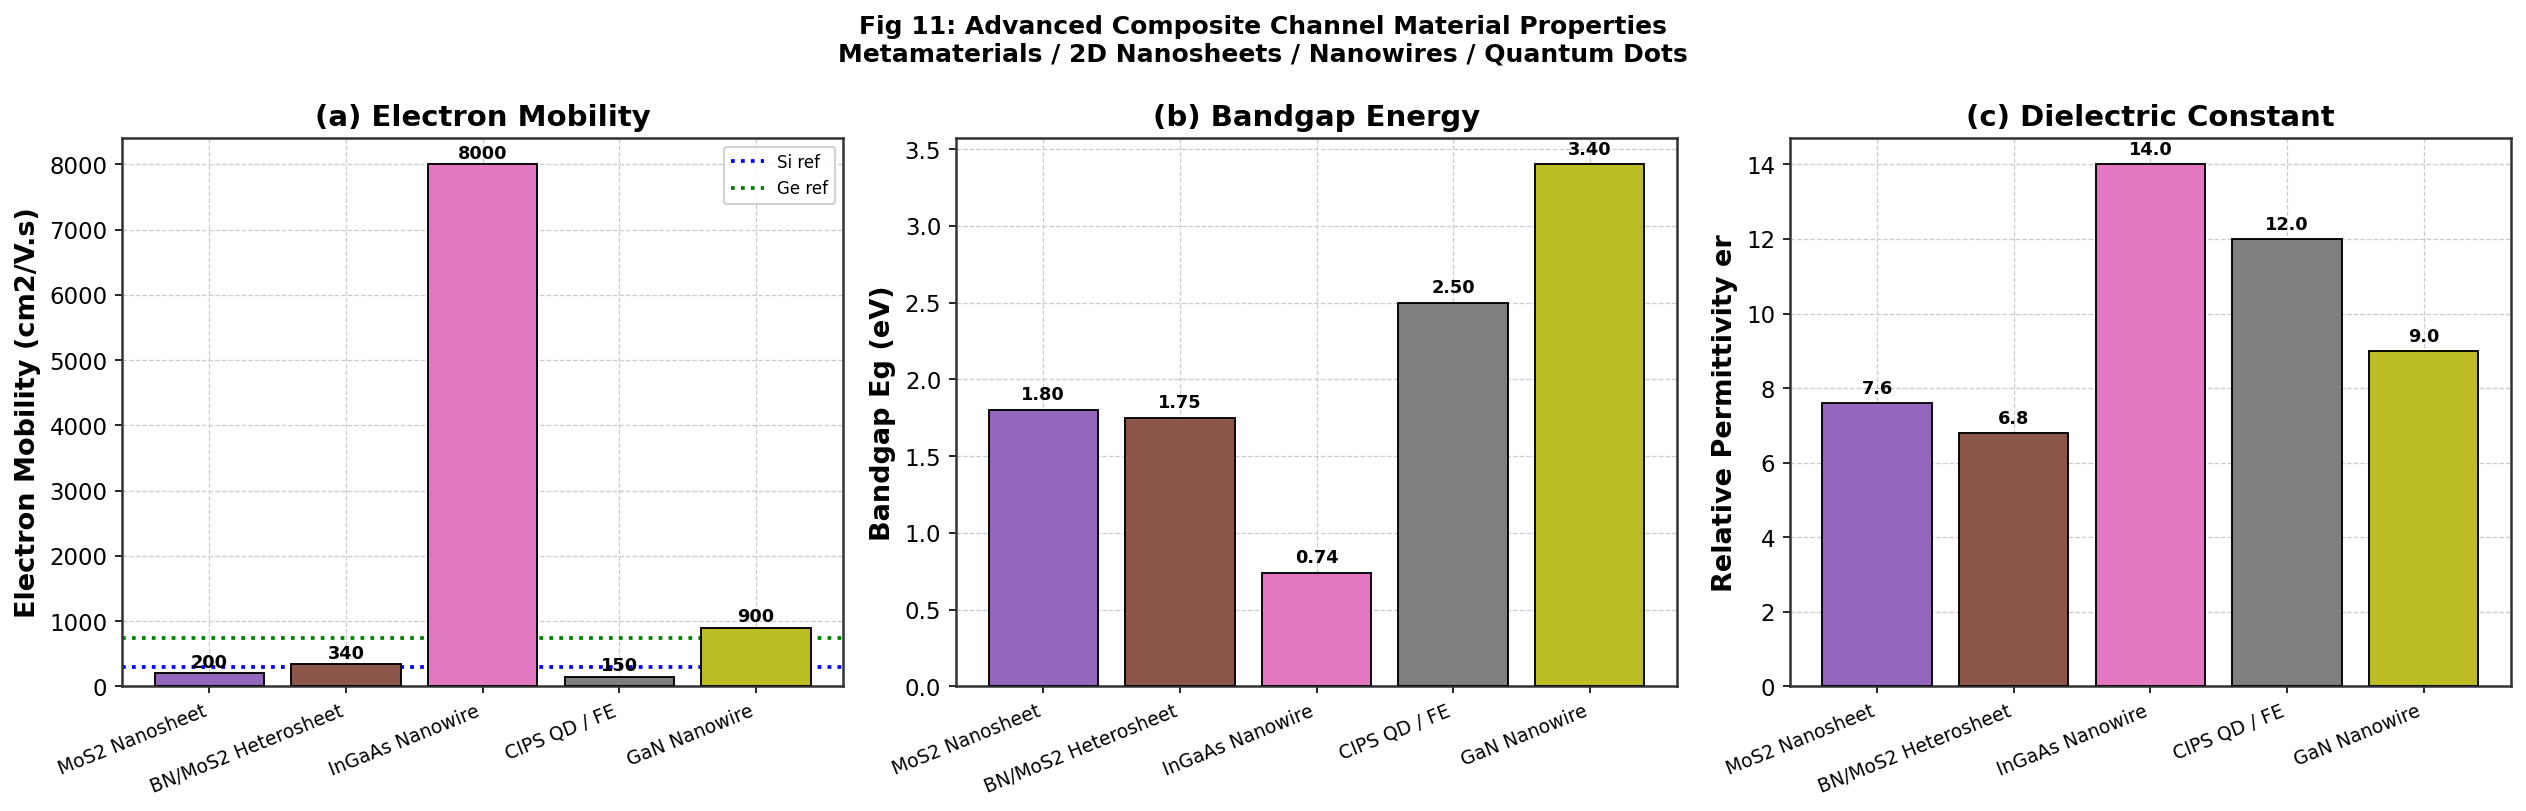

  Saved -> /content/Fig11_NanoMaterial_Properties.png


In [31]:
nano_names = list(NANO.keys())
nano_mu    = [NANO[n]["mu_n"] for n in nano_names]
nano_Eg    = [NANO[n]["Eg"]   for n in nano_names]
nano_eps   = [NANO[n]["eps"]  for n in nano_names]
nano_col   = [NANO[n]["color"] for n in nano_names]
x_pos      = np.arange(len(nano_names))

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# (a) Electron Mobility
bars0 = axes[0].bar(x_pos, nano_mu, color=nano_col, edgecolor="black", linewidth=0.9, zorder=3)
axes[0].axhline(MATERIALS["Si"]["mu_n"],  ls=":", lw=1.8, color="blue",  label="Si ref")
axes[0].axhline(MATERIALS["Ge"]["mu_n"],  ls=":", lw=1.8, color="green", label="Ge ref")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(nano_names, rotation=22, ha="right", fontsize=9)
axes[0].set_ylabel("Electron Mobility (cm2/V.s)")
axes[0].set_title("(a) Electron Mobility", fontweight="bold")
axes[0].legend(fontsize=8)
for b, v in zip(bars0, nano_mu):
    axes[0].text(b.get_x()+b.get_width()/2, v+30, str(v),
                 ha="center", va="bottom", fontsize=8.5, fontweight="bold")

# (b) Bandgap
bars1 = axes[1].bar(x_pos, nano_Eg, color=nano_col, edgecolor="black", linewidth=0.9, zorder=3)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(nano_names, rotation=22, ha="right", fontsize=9)
axes[1].set_ylabel("Bandgap Eg (eV)")
axes[1].set_title("(b) Bandgap Energy", fontweight="bold")
for b, v in zip(bars1, nano_Eg):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.04, f"{v:.2f}",
                 ha="center", va="bottom", fontsize=8.5, fontweight="bold")

# (c) Permittivity
bars2 = axes[2].bar(x_pos, nano_eps, color=nano_col, edgecolor="black", linewidth=0.9, zorder=3)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(nano_names, rotation=22, ha="right", fontsize=9)
axes[2].set_ylabel("Relative Permittivity er")
axes[2].set_title("(c) Dielectric Constant", fontweight="bold")
for b, v in zip(bars2, nano_eps):
    axes[2].text(b.get_x()+b.get_width()/2, v+0.15, f"{v:.1f}",
                 ha="center", va="bottom", fontsize=8.5, fontweight="bold")

title11 = (
    "Fig 11: Advanced Composite Channel Material Properties\n"
    "Metamaterials / 2D Nanosheets / Nanowires / Quantum Dots"
)
fig.suptitle(title11, fontsize=12, fontweight="bold")
save_show(fig, "Fig11_NanoMaterial_Properties.png")


## Figure 12 — Normalised Performance Radar Chart

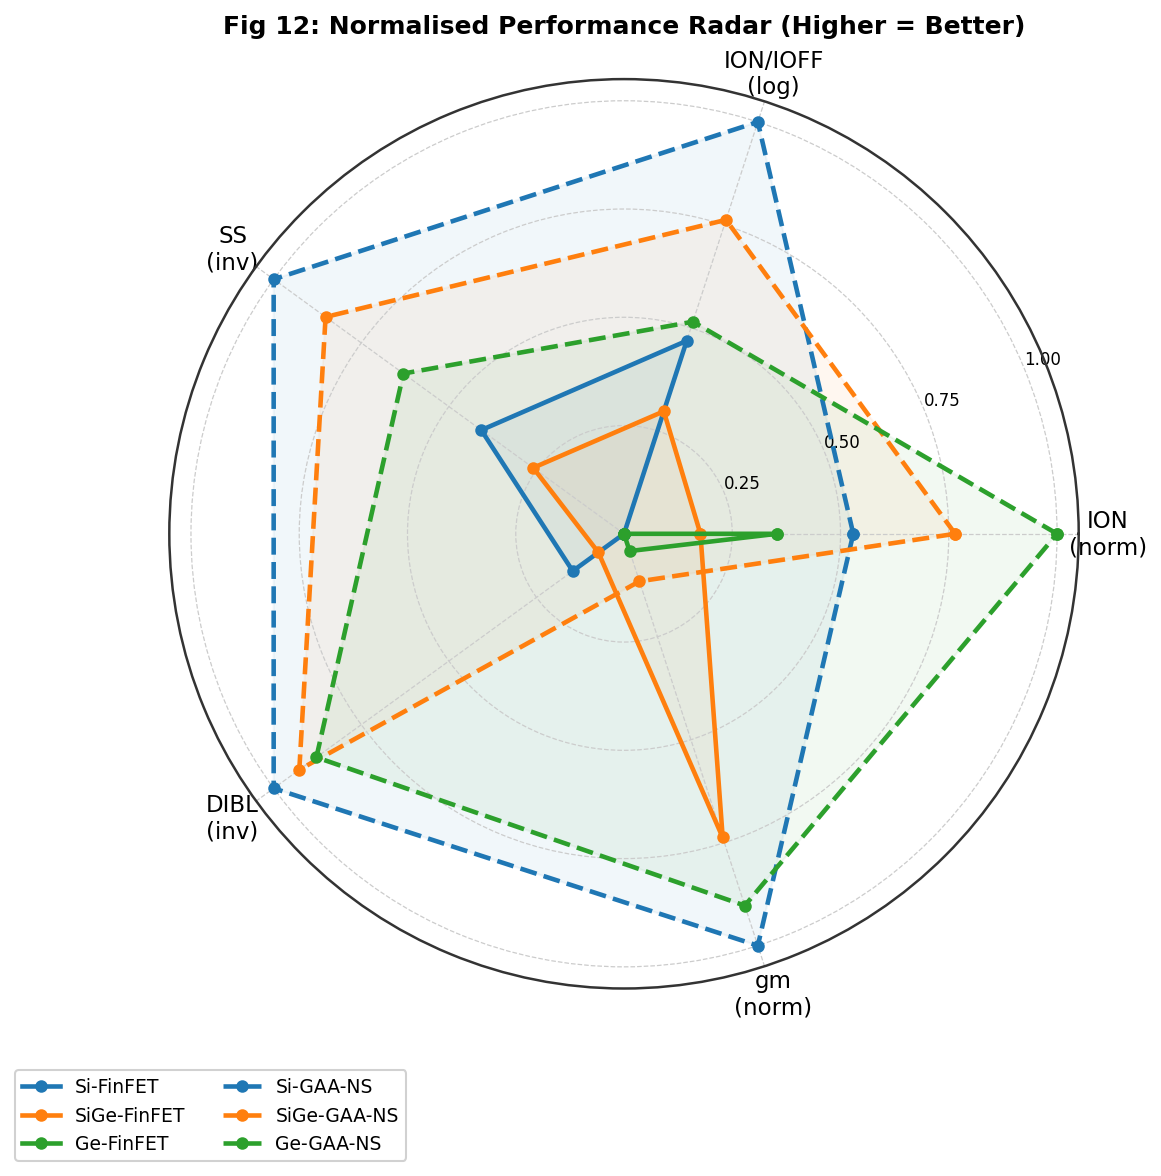

  Saved -> /content/Fig12_Radar_Performance.png


In [32]:
metrics = ["ION\n(norm)", "ION/IOFF\n(log)", "SS\n(inv)", "DIBL\n(inv)", "gm\n(norm)"]
N       = len(metrics)
angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def norm01(v):
    mn, mx = min(v), max(v)
    return [(x-mn)/(mx-mn+1e-30) for x in v]

ION_v  = [FOM[k][2] for k in FOM]
IOF_v  = [np.log10(FOM[k][2]*1e-6/(FOM[k][3]*1e-12)) for k in FOM]
SS_v   = [FOM[k][1] for k in FOM]
DIBL_v = [FOM[k][4] for k in FOM]
gm_v   = [abs(gm_curve(VGS_ARR, 0.05, m, a).max())*1e3
          for m in MAT_LIST for a in ARCH_LIST]

d_ion  = norm01(ION_v)
d_iof  = norm01(IOF_v)
d_ss   = norm01([100-s for s in SS_v])
d_dibl = norm01([100-d for d in DIBL_v])
d_gm   = norm01(gm_v)

COLORS_R = ["#1f77b4","#ff7f0e","#2ca02c","#1f77b4","#ff7f0e","#2ca02c"]
LSS_R    = ["-","-","-","--","--","--"]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
for i, key in enumerate(FOM.keys()):
    vals = [d_ion[i], d_iof[i], d_ss[i], d_dibl[i], d_gm[i]]
    vals = vals + vals[:1]
    ax.plot(angles, vals, color=COLORS_R[i], ls=LSS_R[i], lw=2.2,
            marker="o", ms=5, label=DEV_LABELS[i])
    ax.fill(angles, vals, color=COLORS_R[i], alpha=0.06)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25","0.50","0.75","1.00"], fontsize=8)
ax.set_title("Fig 12: Normalised Performance Radar (Higher = Better)",
             fontsize=12, fontweight="bold", pad=22)
ax.legend(loc="lower left", bbox_to_anchor=(-0.18, -0.20), ncol=2, fontsize=9)
save_show(fig, "Fig12_Radar_Performance.png")


## Tables I–IV — Performance Summary & Device Parameters

In [33]:
try:
    from IPython.display import display
except ImportError:
    display = lambda df: print(df.to_string(index=False))

import pandas as pd

# TABLE I
rows = []
for k in FOM:
    v    = FOM[k]
    Cgg  = Cox * Lg * 1e15
    Pleak= v[3]*1e-12 * VDD * 1e12
    tau  = 4 * Cgg*1e-15 * VDD / (v[2]*1e-6+1e-30) * 1e12
    rows.append({
        "Device": k, "Vth (mV)": v[0], "SS (mV/dec)": v[1],
        "ION (uA/um)": v[2], "IOFF (pA/um)": v[3],
        "ION/IOFF": f"{v[2]*1e-6/(v[3]*1e-12):.2e}",
        "DIBL (mV/V)": v[4], "Pleak (pW/um)": f"{Pleak:.2f}",
        "FO4 tau (ps)": f"{tau:.1f}"
    })
df1 = pd.DataFrame(rows)
print("TABLE I: Comprehensive Performance Parameters")
print(df1.to_string(index=False))
df1.to_csv("/content/Table1_Performance_Summary.csv", index=False)

# TABLE II
rows2 = [{"Material": m, "er": p["eps"], "Eg (eV)": p["Eg"],
          "chi (eV)": p["chi"], "ni (cm-3)": f"{p['ni']:.2e}",
          "mu_n (cm2/Vs)": p["mu_n"], "vsat (e4 m/s)": f"{p['vsat']/1e4:.1f}"}
         for m, p in MATERIALS.items()]
df2 = pd.DataFrame(rows2)
print("\nTABLE II: Channel Material Parameters")
print(df2.to_string(index=False))
df2.to_csv("/content/Table2_Material_Parameters.csv", index=False)

# TABLE III
rows3 = [{"Material": nm, "er": p["eps"], "Eg (eV)": p["Eg"],
          "mu_n (cm2/Vs)": p["mu_n"],
          "Pr (uC/cm2)": str(p["Pr"]) if p["Pr"] else "None",
          "Key Advantage": p["note"]}
         for nm, p in NANO.items()]
df3 = pd.DataFrame(rows3)
print("\nTABLE III: Proposed Advanced Nano-Materials")
print(df3.to_string(index=False))
df3.to_csv("/content/Table3_Nano_Materials.csv", index=False)

# TABLE IV
rows4 = [
    {"Parameter":"Channel material", "FinFET":"Si (100)", "NC-FinFET":"Si (100)"},
    {"Parameter":"Gate length Lg",   "FinFET":"14-30 nm", "NC-FinFET":"10-30 nm"},
    {"Parameter":"Fin height Hfin",  "FinFET":"30 nm",    "NC-FinFET":"30 nm"},
    {"Parameter":"Fin width Wfin",   "FinFET":"8 nm",     "NC-FinFET":"8 nm"},
    {"Parameter":"Gate dielectric",  "FinFET":"SiO2(1nm)/HfO2(2nm)", "NC-FinFET":"SiO2(1nm)/HfO2(3nm)"},
    {"Parameter":"EOT",              "FinFET":"~0.8 nm",  "NC-FinFET":"~0.9 nm"},
    {"Parameter":"Gate electrode",   "FinFET":"TiN 4.5eV","NC-FinFET":"TiN 4.5eV"},
    {"Parameter":"Ferroelectric",    "FinFET":"None",     "NC-FinFET":"PZT 10nm (MPB)"},
    {"Parameter":"Pr",               "FinFET":"None",     "NC-FinFET":"35 uC/cm2"},
    {"Parameter":"Ec",               "FinFET":"None",     "NC-FinFET":"50 kV/cm"},
    {"Parameter":"PZT permittivity", "FinFET":"None",     "NC-FinFET":"~1000"},
    {"Parameter":"VDD",              "FinFET":"0.7 V",    "NC-FinFET":"0.5-0.7 V"},
]
df4 = pd.DataFrame(rows4)
print("\nTABLE IV: NC-FET Gate Stack Parameters")
print(df4.to_string(index=False))
df4.to_csv("/content/Table4_NCFET_GateStack.csv", index=False)
print("\nAll 4 CSV tables saved to /content/")


TABLE I: Comprehensive Performance Parameters
     Device  Vth (mV)  SS (mV/dec)  ION (uA/um)  IOFF (pA/um) ION/IOFF  DIBL (mV/V) Pleak (pW/um) FO4 tau (ps)
  Si-FinFET       220         68.0          900           5.0 1.80e+08           62          3.50    1759999.4
SiGe-FinFET       190         70.0         1050          12.0 8.75e+07           65          8.40    1508570.9
  Ge-FinFET       155         73.5         1200          48.0 2.50e+07           68         33.60    1319999.5
  Si-GAA-NS       195         60.0         1350           0.8 1.69e+09           27          0.56    1173332.9
SiGe-GAA-NS       165         62.0         1550           2.5 6.20e+08           30          1.75    1021935.1
  Ge-GAA-NS       130         65.0         1750           8.0 2.19e+08           32          5.60     905142.5

TABLE II: Channel Material Parameters
Material   er  Eg (eV)  chi (eV) ni (cm-3)  mu_n (cm2/Vs) vsat (e4 m/s)
      Si 11.7     1.12      4.05  1.50e+10            300         

## Final Summary — All Saved Files

In [34]:
import glob
figs = sorted(glob.glob("/content/Fig*.png"))
csvs = sorted(glob.glob("/content/Table*.csv"))
print("=" * 60)
print(f"  Figures saved ({len(figs)}):")
for f in figs:  print(f"    {os.path.basename(f)}")
print(f"  Tables saved  ({len(csvs)}):")
for c in csvs:  print(f"    {os.path.basename(c)}")
print("=" * 60)
print("Download from Files panel (left sidebar) in Colab.")


  Figures saved (12):
    Fig01_ID_VGS_Transfer.png
    Fig02_ID_VDS_Output.png
    Fig03_SubthresholdSwing.png
    Fig04_DIBL_Bar.png
    Fig05_Transconductance.png
    Fig06_ION_IOFF_Ratio.png
    Fig07_ThresholdVoltage.png
    Fig08_IOFF_Leakage.png
    Fig09_PowerDissipation.png
    Fig10_NCFET_SS_vs_tFE.png
    Fig11_NanoMaterial_Properties.png
    Fig12_Radar_Performance.png
  Tables saved  (4):
    Table1_Performance_Summary.csv
    Table2_Material_Parameters.csv
    Table3_Nano_Materials.csv
    Table4_NCFET_GateStack.csv
Download from Files panel (left sidebar) in Colab.


In [35]:
# Download all figures AND CSV tables from Google Colab
import os
from google.colab import files

OUTDIR = "/content"

# Collect figures and tables
to_download = sorted([
    f for f in os.listdir(OUTDIR)
    if (f.endswith(".png") and f.startswith("Fig"))
    or (f.endswith(".csv") and f.startswith("Table"))
])

print(f"Found {len(to_download)} files to download:\n")
for f in to_download:
    print(f"  {f}")

print("\nStarting downloads...\n")
for fname in to_download:
    path = os.path.join(OUTDIR, fname)
    files.download(path)
    print(f"  ✔  {fname}")

print("\n✅ All files downloaded successfully.")

Found 16 files to download:

  Fig01_ID_VGS_Transfer.png
  Fig02_ID_VDS_Output.png
  Fig03_SubthresholdSwing.png
  Fig04_DIBL_Bar.png
  Fig05_Transconductance.png
  Fig06_ION_IOFF_Ratio.png
  Fig07_ThresholdVoltage.png
  Fig08_IOFF_Leakage.png
  Fig09_PowerDissipation.png
  Fig10_NCFET_SS_vs_tFE.png
  Fig11_NanoMaterial_Properties.png
  Fig12_Radar_Performance.png
  Table1_Performance_Summary.csv
  Table2_Material_Parameters.csv
  Table3_Nano_Materials.csv
  Table4_NCFET_GateStack.csv

Starting downloads...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✔  Fig01_ID_VGS_Transfer.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✔  Table3_Nano_Materials.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✔  Table4_NCFET_GateStack.csv

✅ All files downloaded successfully.
